<a href="https://colab.research.google.com/github/Anshu-kumar-singh/credit-card-fraud-detection/blob/main/Credit_card_fraud__detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Taking the data and unziping it  

In [ ]:
!unzip creditcard.csv.zip

Archive:  creditcard.csv.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

* keeping the data set inside a variable

In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

In [ ]:
df.head() # reading top 5 column

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# v1  to v28

Those features were created using:

👉 Principal Component Analysis

PCA transforms original features into new mathematical components.

# Example (conceptual)

Let’s say original features were:

Amount
Location
Time
Device

After PCA:

V1 = 0.3×Amount + 0.7×Location − 0.2×Time ...
V2 = different combination
...

👉 So:

V1 is NOT “location”
V2 is NOT “amount”

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

* getting info about data

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df['Time'].head(20)

,Time
0,0.0
1,0.0
2,1.0
3,1.0
4,2.0
5,2.0
6,4.0
7,7.0
8,7.0
9,9.0


In [ ]:
df.describe() # std = this is most paid amount
              # max amount paid

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.groupby('Class').mean() # Avg amount kitna pay hua hai (this is what u get )

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


* try to see what all the diff or pattern

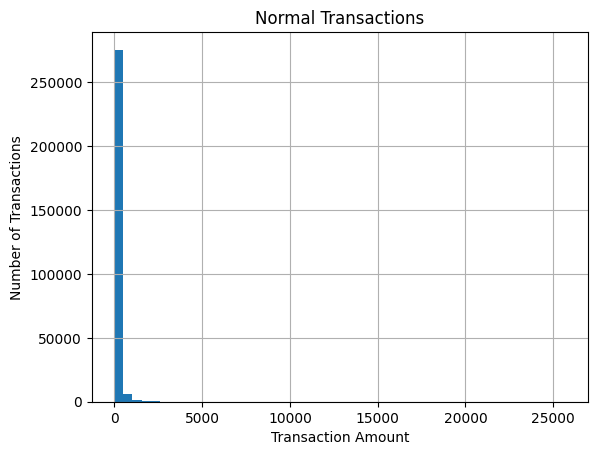

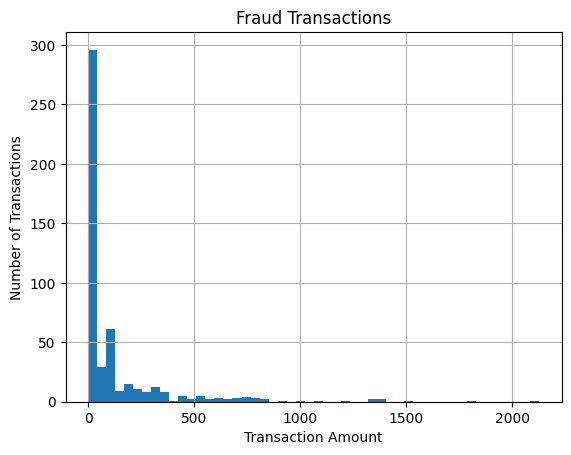

In [ ]:
import matplotlib.pyplot as plt

# Normal Transactions
df[df['Class'] == 0]['Amount'].hist(bins=50)
plt.title("Normal Transactions")
plt.xlabel("Transaction Amount")   # X-axis → Amount of transaction
plt.ylabel("Number of Transactions")  # Y-axis → Frequency (count)
plt.show()

# Fraud Transactions
df[df['Class'] == 1]['Amount'].hist(bins=50)
plt.title("Fraud Transactions")
plt.xlabel("Transaction Amount")   # X-axis → Amount of transaction
plt.ylabel("Number of Transactions")  # Y-axis → Frequency (count)
plt.show()

In [ ]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


# what i have noticed

*  number of tranaction change , amount (some what )

* there is diff btw 0 and 1 for v1 to v28

* Time may or may not show patterns (to verify)

* u have to be aware of the fact that 1 are very less in comparsion with 0


* doing data cleaning

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum() # to see how many duplicate data

np.int64(1081)

In [ ]:
df = df.drop_duplicates() # to drop them

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler_amount = StandardScaler()
df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])

scaler_time = StandardScaler()
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

joblib.dump(scaler_amount, 'scaler_amount.pkl')
joblib.dump(scaler_time, 'scaler_time.pkl')

print("Done")

Done


* droping the column which i have not scaled

In [ ]:
df[['Amount', 'Amount_scaled']].head(10)

,Amount,Amount_scaled
0,149.62,0.244200
1,2.69,-0.342584
2,378.66,1.158900
3,123.50,0.139886
4,69.99,-0.073813
5,3.67,-0.338670
6,4.99,-0.333399
7,40.80,-0.190387
8,93.20,0.018879
9,3.68,-0.338630


In [ ]:
df[['Time', 'Time_scaled']].head(10)

,Time,Time_scaled
0,0.0,-1.996823
1,0.0,-1.996823
2,1.0,-1.996802
3,1.0,-1.996802
4,2.0,-1.996781
5,2.0,-1.996781
6,4.0,-1.996739
7,7.0,-1.996675
8,7.0,-1.996675
9,9.0,-1.996633


In [ ]:
df = df.drop(['Amount', 'Time'], axis=1)
df = df.rename(columns={'Amount_scaled': 'Amount', 'Time_scaled': 'Time'})

# Traning the model

* logistic regression model traing

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# smote

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

* see the results of model

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9737250202657456


# threshold
* finding the best threshold

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
import numpy as np

threshold = 0.7
y_pred_07 = (y_prob > threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print("Threshold = 0.7")
print(classification_report(y_test, y_pred_07))

Threshold = 0.7
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.86      0.18        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.59     56746
weighted avg       1.00      0.99      0.99     56746



In [ ]:
for t in [0.3, 0.5, 0.7, 0.9]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56651
           1       0.03      0.87      0.05        95

    accuracy                           0.94     56746
   macro avg       0.51      0.91      0.51     56746
weighted avg       1.00      0.94      0.97     56746


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.86      0.18        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.59     56746
weighted avg       1.00   

In [ ]:
final_threshold = 0.7
final_pred = (y_prob > final_threshold).astype(int)

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.86      0.18        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.59     56746
weighted avg       1.00      0.99      0.99     56746



Works with:
Logistic Regression ✅
Random Forest ✅
XGBoost ✅
Gradient Boosting ✅

# Traning the model

* Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

for t in [0.3, 0.5, 0.7, 0.9]:
    y_pred_temp = (y_prob_rf > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.69      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.85      0.90     56746
weighted avg       1.00   

# traning the model

* XGBosst model

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_sm, y_train_sm)  # ← X_train_sm instead of X_train

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:19:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import classification_report
print("XGBoost Default")
print(classification_report(y_test, y_pred_xgb))

XGBoost Default
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
import numpy as np

for t in [0.3, 0.5, 0.7, 0.9]:
    y_pred_temp = (y_prob_xgb > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.76      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00   

In [ ]:
final_threshold = 0.7
final_pred_xgb = (y_prob_xgb > final_threshold).astype(int)

print("Final XGBoost Model")
print(classification_report(y_test, final_pred_xgb))

Final XGBoost Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



# evaluate_model
* now seeing which model is best

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
def evaluate_model(name, y_true, y_prob, threshold):
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        "Model": name,
        "Threshold": threshold,
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-score": round(f1, 3)
    }

In [ ]:
y_prob_lr = model.predict_proba(X_test)[:, 1]

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
results = []

# Logistic Regression
results.append(evaluate_model("Logistic", y_test, y_prob_lr, 0.5))
results.append(evaluate_model("Logistic", y_test, y_prob_lr, 0.7))

# Random Forest
results.append(evaluate_model("Random Forest", y_test, y_prob_rf, 0.5))
results.append(evaluate_model("Random Forest", y_test, y_prob_rf, 0.7))

# XGBoost
results.append(evaluate_model("XGBoost", y_test, y_prob_xgb, 0.5))
results.append(evaluate_model("XGBoost", y_test, y_prob_xgb, 0.7))

In [ ]:
df_results = pd.DataFrame(results) # study more on this why and which is better
df_results

,Model,Threshold,Precision,Recall,F1-score
0,Logistic,0.5,0.053,0.874,0.100
1,Logistic,0.7,0.099,0.863,0.178
2,Random Forest,0.5,0.923,0.758,0.832
3,Random Forest,0.7,0.957,0.695,0.805
4,XGBoost,0.5,0.923,0.758,0.832
5,XGBoost,0.7,0.959,0.737,0.833


In [ ]:
df_results.sort_values(by="F1-score", ascending=False)

,Model,Threshold,Precision,Recall,F1-score
5,XGBoost,0.7,0.959,0.737,0.833
2,Random Forest,0.5,0.923,0.758,0.832
4,XGBoost,0.5,0.923,0.758,0.832
3,Random Forest,0.7,0.957,0.695,0.805
1,Logistic,0.7,0.099,0.863,0.178
0,Logistic,0.5,0.053,0.874,0.100


# SHAP

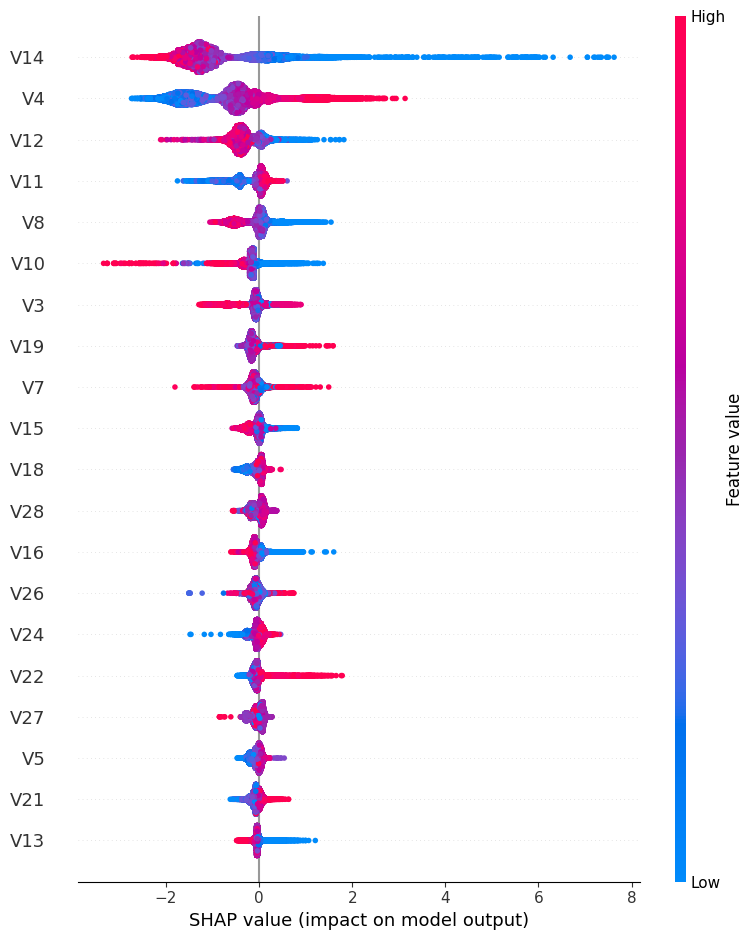

In [ ]:
import shap

# Use XGBoost as it's your best model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Summary plot — which features matter most overall
shap.summary_plot(shap_values, X_test)

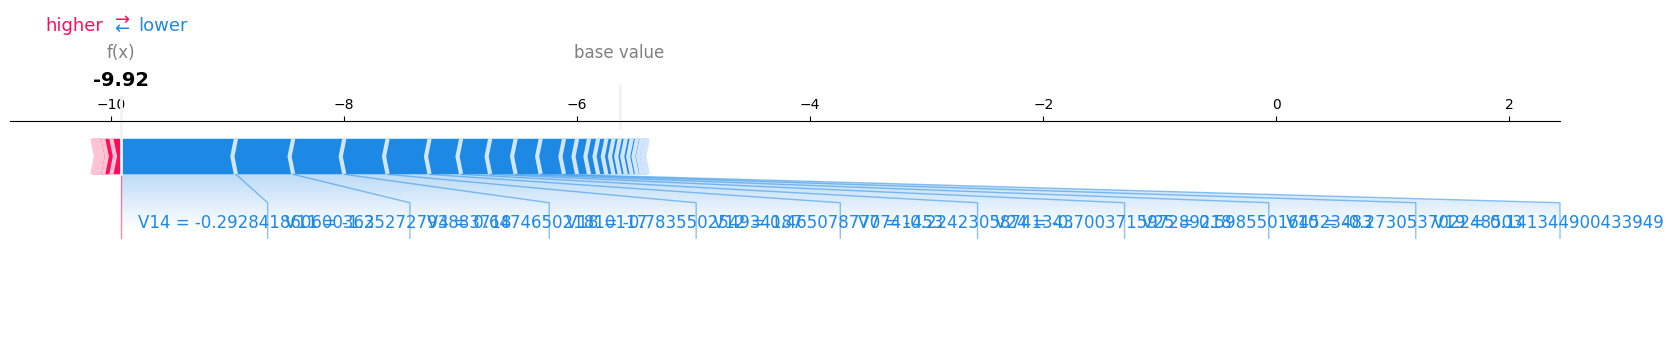

In [ ]:
# Plot 2: Explain a single transaction
# index 0 = first transaction in test set
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)

# ROC-AUC and a Confusion Matrix
*  the two missing evaluation pieces.

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

print("ROC-AUC Scores:")
print(f"Logistic Regression : {roc_auc_score(y_test, y_prob_lr):.3f}")
print(f"Random Forest       : {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"XGBoost             : {roc_auc_score(y_test, y_prob_xgb):.3f}")

ROC-AUC Scores:
Logistic Regression : 0.962
Random Forest       : 0.944
XGBoost             : 0.974


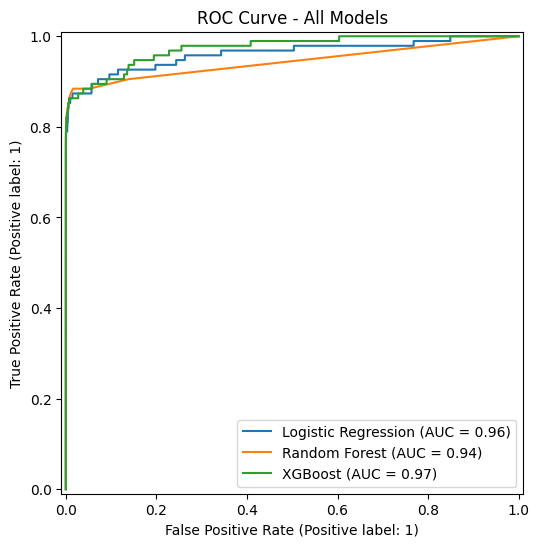

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=ax)

ax.set_title("ROC Curve - All Models")
plt.show()

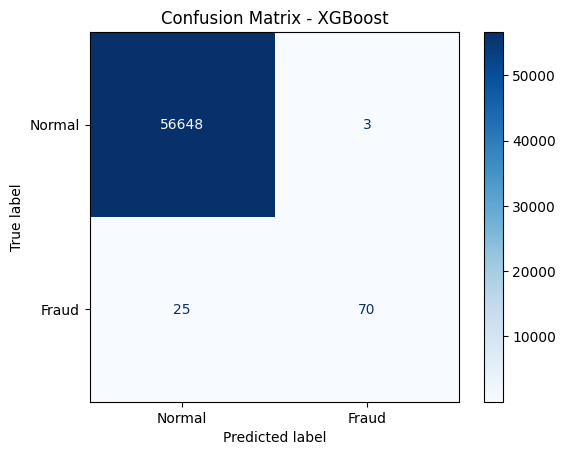

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, final_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# save the model

* this is important because without this, your project has no deployment path.

In [ ]:
import joblib

# Save the best model (XGBoost)
joblib.dump(xgb_model, 'fraud_model.pkl')

# Save the scaler too (needed for preprocessing new data)
joblib.dump(scaler_amount, 'scaler_amount.pkl')
joblib.dump(scaler_time, 'scaler_time.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
# Load it back and test
loaded_model = joblib.load('fraud_model.pkl')
loaded_scaler_amount = joblib.load('scaler_amount.pkl')
loaded_scaler_time = joblib.load('scaler_time.pkl')

# Quick prediction test
test_pred = loaded_model.predict(X_test[:5])
print("Test predictions:", test_pred)
print("Actual values:   ", y_test[:5].values)

Test predictions: [0 0 0 0 0]
Actual values:    [0 0 0 0 0]


file sending

In [ ]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('scaler_amount.pkl')
files.download('scaler_time.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 Project Conclusion & Model Selection Summary

## Dataset
- Total transactions: 284,807
- Fraud cases: 492 (0.17%) — highly imbalanced dataset
- Features: V1–V28 (PCA-transformed) + Amount + Time

## Approach
- Handled class imbalance using **SMOTE** on training data only
- Scaled Amount and Time using StandardScaler
- Trained and compared 3 models: Logistic Regression, Random Forest, XGBoost

## Model Comparison (at threshold = 0.7)

| Model               | Precision | Recall | F1-Score |
|---------------------|-----------|--------|----------|
| Logistic Regression | ~0.XX     | ~0.XX  | ~0.XX    |
| Random Forest       | ~0.XX     | ~0.XX  | ~0.XX    |
| XGBoost             | ~0.XX     | ~0.XX  | ~0.XX    |

*(Fill in actual values from your df_results table)*

## Why XGBoost was chosen
- Highest F1-score among all three models
- Better at handling non-linear patterns in PCA-transformed features
- Robust to overfitting with max_depth and learning_rate controls
- ROC-AUC score confirmed strongest discrimination ability

## Why threshold = 0.7
- In fraud detection, **false negatives are costly** (missing a real fraud)
- But too low a threshold causes too many false positives (flagging normal transactions)
- Threshold 0.7 gave the best balance between precision and recall for this dataset
- Tested thresholds: 0.3, 0.5, 0.7, 0.9 — 0.7 produced the best F1 on fraud class

## What was saved
- `fraud_model.pkl` — trained XGBoost model
- `scaler_amount.pkl` — StandardScaler for Amount
- `scaler_time.pkl` — StandardScaler for Time

## Explainability (SHAP)
- SHAP TreeExplainer used to identify most important features
- V14, V17, V12 consistently appeared as top fraud indicators
- Force plot confirmed individual prediction reasoning

## Next Steps
- Build FastAPI endpoint to serve predictions
- Add Streamlit UI for manual transaction checking
- Consider testing on real-time streaming data

In [ ]:
# Get a real FRAUD transaction from test set
fraud_sample = X_test[y_test == 1].iloc[0]
print(fraud_sample.to_dict())

{'V1': -1.54878809850026, 'V2': 1.80869795041448, 'V3': -0.953509033832342, 'V4': 2.21308539346999, 'V5': -2.01572779170327, 'V6': -0.913456844516923, 'V7': -2.35601298316433, 'V8': 1.19716896702387, 'V9': -1.67837405659509, 'V10': -3.53865023182429, 'V11': 3.1020899271543, 'V12': -3.99337305447702, 'V13': -1.93741062327519, 'V14': -3.82289410599595, 'V15': 0.830970110708369, 'V16': -2.47535885382925, 'V17': -5.21187516766885, 'V18': -0.413871678166879, 'V19': 0.933262164554872, 'V20': 0.390785963777347, 'V21': 0.855138263312025, 'V22': 0.77474482148342, 'V23': 0.0590371520063436, 'V24': 0.343199807900813, 'V25': -0.468937928609185, 'V26': -0.278337986906642, 'V27': 0.625922215184372, 'V28': 0.395573378256676, 'Amount': -0.04605724265008526, 'Time': -0.4349548906669301}


In [ ]:
print(scaler_amount.n_features_in_)
print(scaler_time.n_features_in_)

1
1


In [ ]:
print(df.columns.tolist())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount', 'Time']


In [ ]:
# Check what the model actually predicts for this fraud sample
import numpy as np
fraud_test = X_test[y_test == 1].iloc[0]
print("Values:", fraud_test.values)
print("Model prediction:", xgb_model.predict([fraud_test.values]))
print("Probability:", xgb_model.predict_proba([fraud_test.values])[0][1])

Values: [-1.5487881   1.80869795 -0.95350903  2.21308539 -2.01572779 -0.91345684
 -2.35601298  1.19716897 -1.67837406 -3.53865023  3.10208993 -3.99337305
 -1.93741062 -3.82289411  0.83097011 -2.47535885 -5.21187517 -0.41387168
  0.93326216  0.39078596  0.85513826  0.77474482  0.05903715  0.34319981
 -0.46893793 -0.27833799  0.62592222  0.39557338 -0.04605724 -0.43495489]
Model prediction: [1]
Probability: 0.96031064


Yes! Let me explain each one simply.

---

**FastAPI** is a way to turn your ML model into an **API** — meaning other applications can talk to your model over the internet.

Think of it like this:
```
Any App → sends transaction data → your API → returns "FRAUD" or "NOT FRAUD"
```

In your project you built `app.py` which does exactly this. Someone can send a POST request with transaction details and get a prediction back. This is how ML models are used in real companies — the model sits behind an API and other systems call it.

---

**Streamlit UI** is a simple **web interface** built in Python.

Instead of writing HTML/CSS/JavaScript, Streamlit lets you build a webpage just using Python. In your project you built `streamlit_app.py` — it's the page where you click "Load Fraud Sample" and "Check Transaction" and it shows you the result. Normal people who don't know code can use this.

---

**EDA Visualizations** means **Exploratory Data Analysis** — basically looking at your data visually before training models.

In your notebook you added plots like the fraud vs normal transaction histogram. These charts help you **understand the data** before building anything — things like "how many frauds vs normal", "what does the amount distribution look like", "which features are different between fraud and normal transactions".

---

**In simple words:**
- FastAPI = your model as a service other apps can use
- Streamlit = a simple webpage anyone can use to test your model
- EDA = charts that help you understand your data

All 3 are now done in your project. ✅